Purpose: Find shared & unique TSGs & DEGs from different Yg physiotypes.<br>
Author: Anna Pardo<br>
Date initiated: July 10, 2026

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from venn import venn

In [2]:
# load DEGs for Yg
camde = json.load(open("./CAM_DEGs_by_x_overlap_July2026.json"))
c3de = json.load(open("./C3+CAM_DEGs_by_x_overlap_July2026.json"))
facde = json.load(open("./facCAM_DEGs_by_x_overlap_July2026.json"))

In [3]:
# load TSGs for Yg
c3cam = pd.read_csv("./C3+CAM_TSgenes_9gt_e05.txt",sep="\t",header="infer")
cam = pd.read_csv("./CAM_TSgenes_9gt_e05.txt",sep="\t",header="infer")
faccam = pd.read_csv("./facCAM_TSgenes_9gt_e05.txt",sep="\t",header="infer")

In [4]:
# make Venn diagrams of TSGs & DEGs
def venn_degs(thresh,saveplot=True,d="./"):
    thresh = str(thresh)
    venndict = {
        "CAM":set(camde[thresh]),
        "C3+CAM":set(c3de[thresh]),
        "facultative CAM":set(facde[thresh])
    }
    
    venn(venndict)
    plt.title("Y. gloriosa DEGs overlap (threshold="+thresh+" data subsets)",fontsize=20)
    
    if saveplot:
        if not os.path.exists(d):
            os.makedirs(d)
        
        fbase = "Yg_DEGs_venn_"+thresh+"subsets"
        plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

In [36]:
len(set(facde["8"]))

28

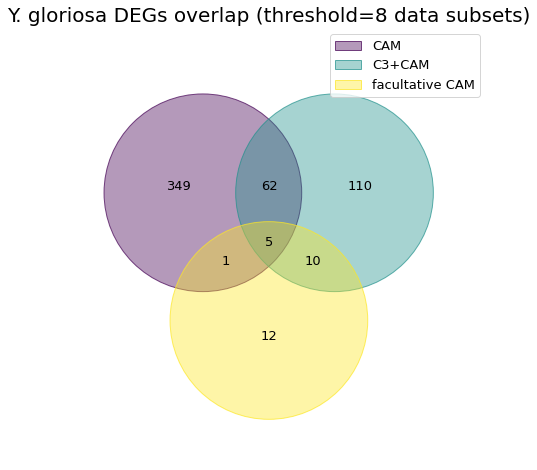

In [5]:
venn_degs(8,True,"./deg_tsg_venns")

In [6]:
cam.head()

,GeneID,subgenome,physiology
0,Yucal.03G175800.v2.1,Ya,CAM
1,YufilH1050481m.g,Yf,CAM
2,YufilH1079637m.g,Yf,CAM
3,Yucal.01G008100.v2.1,Ya,CAM
4,YufilH1084105m.g,Yf,CAM


In [7]:
# make Venn diagram of TSGs
venntsg = {
    "CAM":set(cam["GeneID"]),
    "C3+CAM":set(c3cam["GeneID"]),
    "facultative CAM":set(faccam["GeneID"])
}

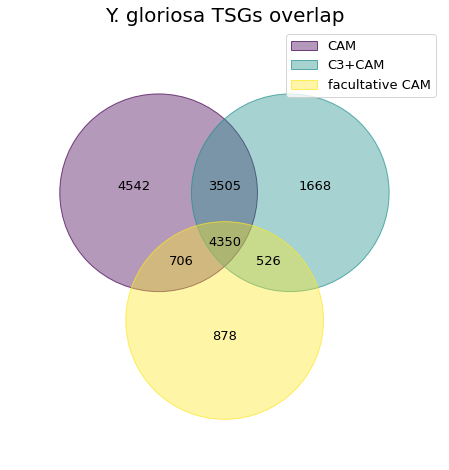

In [8]:
venn(venntsg)
plt.title("Y. gloriosa TSGs overlap",fontsize=20)

plt.savefig("./deg_tsg_venns/Yg_TSGs_venn.png",dpi=300,bbox_inches="tight")
plt.savefig("./deg_tsg_venns/Yg_TSGs_venn.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./deg_tsg_venns/Yg_TSGs_venn.svg",dpi=300,bbox_inches="tight")

In [9]:
cam.head()

,GeneID,subgenome,physiology
0,Yucal.03G175800.v2.1,Ya,CAM
1,YufilH1050481m.g,Yf,CAM
2,YufilH1079637m.g,Yf,CAM
3,Yucal.01G008100.v2.1,Ya,CAM
4,YufilH1084105m.g,Yf,CAM


In [10]:
# get out the actual gene lists
# first: three-way shared TSGs
dfs = [cam, c3cam, faccam]

tsgs3way = list(
    set.intersection(*(set(df["GeneID"]) for df in dfs))
)

In [11]:
# save 3-way intersection TSGs
with open("./3way_TSGs_Yg_allphys.txt","w+") as outfile:
    for i in tsgs3way:
        outfile.write(i+"\n")

In [31]:
ya = [i for i in tsgs3way if i.startswith("Yucal")]
yf = [i for i in tsgs3way if i.startswith("Yufil")]

In [32]:
len(ya)

2600

In [33]:
len(yf)

1750

In [12]:
# get lists of unique DEGs & merge with gene annotation for Karolina
# load annotations
yaannot = pd.read_csv("../gene_annotations/Y_aloifolia.emapper.annotations.tsv",sep="\t",header=None,comment="#")

In [13]:
yaannot.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,Yucal.1Z013500.1.p,4641.GSMUA_Achr1P08280_001,2.290000e-161,467.0,"28JMV@1|root,2QS10@2759|Eukaryota,37J0Q@33090|...",35493|Streptophyta,S,ACT domain containing protein,-,-,...,-,-,-,-,-,-,-,-,-,"ACT,ACT_6"
1,Yucal.1Z065500.1.p,42345.XP_008781230.1,4.650000e-135,397.0,"COG0515@1|root,KOG0192@2759|Eukaryota,37N3E@33...",35493|Streptophyta,T,Serine threonine-protein kinase,-,"GO:0003674,GO:0003824,GO:0004672,GO:0005575,GO...",...,ko:K00799,"ko00480,ko00980,ko00982,ko00983,ko01524,ko0520...",-,"R03522,R07002,R07003,R07004,R07023,R07024,R070...","RC00004,RC00069,RC00840,RC00948,RC01704,RC0170...","ko00000,ko00001,ko01000,ko02000","1.A.12.2.2,1.A.12.3.2",-,-,"ACT,Pkinase_Tyr"
2,Yucal.1Z302100.1.p,42345.XP_008785794.1,2.360000e-150,440.0,"KOG3683@1|root,KOG3683@2759|Eukaryota,37M6K@33...",35493|Streptophyta,S,DUF1767,-,-,...,ko:K18404,-,-,-,-,"ko00000,ko03019,ko03036",-,-,-,RMI1_N
3,Yucal.1Z302200.1.p,42345.XP_008809006.1,6.420000e-124,360.0,"COG0605@1|root,KOG0876@2759|Eukaryota,37RMW@33...",35493|Streptophyta,P,radicals which are normally produced within th...,-,"GO:0000302,GO:0000303,GO:0000305,GO:0003674,GO...",...,ko:K04564,"ko04013,ko04068,ko04146,ko04211,ko04212,ko0421...",-,-,-,"ko00000,ko00001,ko01000",-,-,-,"Sod_Fe_C,Sod_Fe_N"
4,Yucal.1Z302000.1.p,42345.XP_008785831.1,4.730000e-264,749.0,"28JRK@1|root,2QS51@2759|Eukaryota,37MB5@33090|...",35493|Streptophyta,S,Protein FAR1-RELATED SEQUENCE,-,"GO:0003674,GO:0003700,GO:0005575,GO:0005622,GO...",...,ko:K17604,-,-,-,-,"ko00000,ko01009",-,-,-,"FAR1,MULE,SWIM"


In [14]:
yfannot = pd.read_csv("../gene_annotations/Yfv3_Hap1_genefunctions.txt",sep="\t",header="infer")
yfannot.head()

,locusName,Id,IdType,"description if any, GO is via pfam2go/interpro"
0,YufilH1039891m.g,K01213,KEGGORTH,"galacturan 1,4-alpha-galacturonidase [EC:3.2.1..."
1,YufilH1039891m.g,GO:0005975,GO,carbohydrate metabolic process
2,YufilH1039891m.g,PF00295,PFAM,Glycosyl hydrolases family 28
3,YufilH1039891m.g,3.2.1.15,EC,Polygalacturonase.
4,YufilH1039891m.g,GO:0004650,GO,polygalacturonase activity


In [15]:
yaannot[0] = yaannot[0].str.split(".1.p").str[0]+".v2.1"

In [16]:
yaannot = yaannot[[0,9,7]]

In [17]:
yaannot.head()

,0,9,7
0,Yucal.1Z013500.v2.1,-,ACT domain containing protein
1,Yucal.1Z065500.v2.1,"GO:0003674,GO:0003824,GO:0004672,GO:0005575,GO...",Serine threonine-protein kinase
2,Yucal.1Z302100.v2.1,-,DUF1767
3,Yucal.1Z302200.v2.1,"GO:0000302,GO:0000303,GO:0000305,GO:0003674,GO...",radicals which are normally produced within th...
4,Yucal.1Z302000.v2.1,"GO:0003674,GO:0003700,GO:0005575,GO:0005622,GO...",Protein FAR1-RELATED SEQUENCE


In [18]:
yfannot = yfannot[["locusName","Id","description if any, GO is via pfam2go/interpro"]]

In [19]:
yfannot.rename(columns={"locusName":"GeneID","Id":"ID","description if any, GO is via pfam2go/interpro":"Description"},
              inplace=True)

In [20]:
yaannot.rename(columns={0:"GeneID",9:"ID",7:"Description"},inplace=True)

In [21]:
# append annotations together
ygannot = pd.concat([yaannot,yfannot])

In [22]:
# get unique DEG lists for each physiotype
def get_unique_degs(ptype):
    venndict = {
        "CAM":set(camde["8"]),
        "C3+CAM":set(c3de["8"]),
        "facultative CAM":set(facde["8"])
    }
    
    nonptype = []
    for i in venndict.keys():
        if i != ptype:
            nonptype.append(i)
    
    diff = list(venndict[ptype].difference(venndict[nonptype[0]],venndict[nonptype[1]]))
    return diff

In [23]:
def make_uniqueDEGs_df(ptype):
    dfdict = {"unique_DEG_IDs":get_unique_degs(ptype),"physiotype":ptype}
    df = pd.DataFrame(dfdict)
    df = df.merge(ygannot.rename(columns={"GeneID":"unique_DEG_IDs"}),how="left")
    df = df.drop("ID",axis=1)
    return df

In [24]:
dfl = []
for i in ["facultative CAM","CAM","C3+CAM"]:
    dfl.append(make_uniqueDEGs_df(i))
unique_degs = pd.concat(dfl)

In [25]:
unique_degs.to_csv("./Yg_physiotype_unique_DEGs_withannot.csv",sep=",",header=True,index=False)

In [26]:
# save ygannot
ygannot.to_csv("./Ya_Yfv3H1_gene_functions.txt",sep="\t",header=True,index=False)

In [37]:
# what are the three-way shared DEGs?
venndict = {
    "CAM":set(camde["8"]),
    "C3+CAM":set(c3de["8"]),
    "facultative CAM":set(facde["8"])
}

In [39]:
shared_degs = list(set.intersection(*venndict.values()))

In [41]:
ygannot[ygannot["GeneID"].isin(shared_degs)]

,GeneID,ID,Description
2096,Yucal.24G008200.v2.1,-,Heat stress transcription factor
32118,Yucal.07G030900.v2.1,"GO:0005575,GO:0005622,GO:0005623,GO:0005737,GO...",Belongs to the small heat shock protein (HSP20...
4809,YufilH1087063m.g,PTHR11527,SMALL HEAT-SHOCK PROTEIN (HSP20) FAMILY
4810,YufilH1087063m.g,PF00011,Hsp20/alpha crystallin family
4811,YufilH1087063m.g,K13993,HSP20 family protein
4812,YufilH1087063m.g,PTHR11527:SF325,NaN
4813,YufilH1087063m.g,KOG3591,Alpha crystallins
166574,YufilH1078011m.g,PF01964,ThiC family
166575,YufilH1078011m.g,PTHR30557,THIAMINE BIOSYNTHESIS PROTEIN THIC
166576,YufilH1078011m.g,PTHR30557:SF2,NaN


In [42]:
shared_degs

['YufilH1087063m.g',
 'YufilH1086562m.g',
 'Yucal.07G030900.v2.1',
 'Yucal.24G008200.v2.1',
 'YufilH1078011m.g']